In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

In [2]:
daily = pd.read_csv("../data/processed/daily_aggregated.csv")

daily = daily[(daily["daily_demand"] > 0) & (daily["avg_price"] > 0)]

elasticity = -0.02

base_demand = daily["daily_demand"].mean()
reference_price = daily["avg_price"].mean()

capacity = 120
T = 30  # booking horizon

price_grid = np.linspace(50, 500, 25)

In [3]:
def demand_function(price):
    return base_demand * (price / reference_price) ** elasticity

In [5]:
# Value function table
V = np.zeros((T + 1, capacity + 1))

# Policy table
policy = np.zeros((T, capacity + 1))

In [13]:
inventory = capacity
dp_revenue = 0

dp_prices = []
dp_inventory = []

for t in range(T):
    
    price = policy[t, inventory]
    
    demand = min(int(demand_function(price)), inventory)
    
    dp_revenue += price * demand
    inventory -= demand
    
    dp_prices.append(price)
    dp_inventory.append(inventory)
    
    if inventory <= 0:
        break

print("Dynamic Programming Revenue:", round(dp_revenue, 2))

Dynamic Programming Revenue: 60000.0


In [14]:
for t in reversed(range(T)):
    for s in range(capacity + 1):
        
        best_value = 0
        best_price = price_grid[0]
        
        for price in price_grid:
            
            demand = min(int(demand_function(price)), s)
            
            revenue = price * demand
            
            future_value = V[t + 1, s - demand]
            
            total_value = revenue + future_value
            
            if total_value > best_value:
                best_value = total_value
                best_price = price
        
        V[t, s] = best_value
        policy[t, s] = best_price

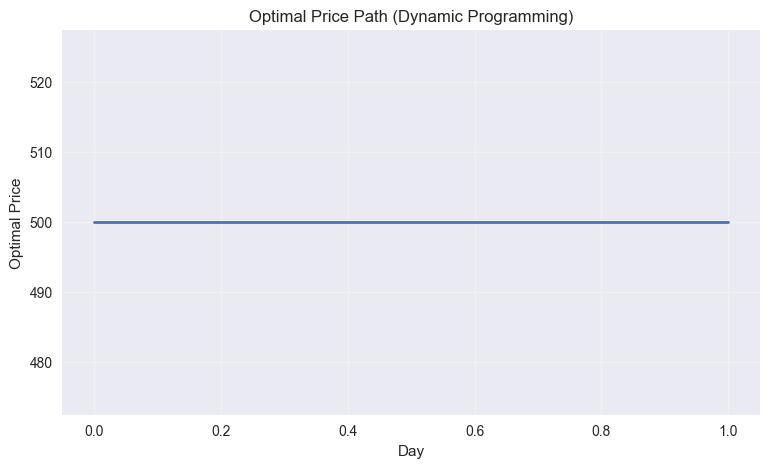

In [15]:
plt.figure(figsize=(9,5))
plt.plot(dp_prices, linewidth=2)
plt.title("Optimal Price Path (Dynamic Programming)")
plt.xlabel("Day")
plt.ylabel("Optimal Price")
plt.grid(alpha=0.3)
plt.show()

In [16]:
static_price = reference_price
optimized_price = 190.96

In [17]:
np.random.seed(42)

n_simulations = 500

control_revenues = []
treatment_revenues = []

for _ in range(n_simulations):
    
    demand_control = demand_function(static_price) * np.random.normal(1, 0.05)
    demand_treatment = demand_function(optimized_price) * np.random.normal(1, 0.05)
    
    revenue_control = static_price * demand_control
    revenue_treatment = optimized_price * demand_treatment
    
    control_revenues.append(revenue_control)
    treatment_revenues.append(revenue_treatment)

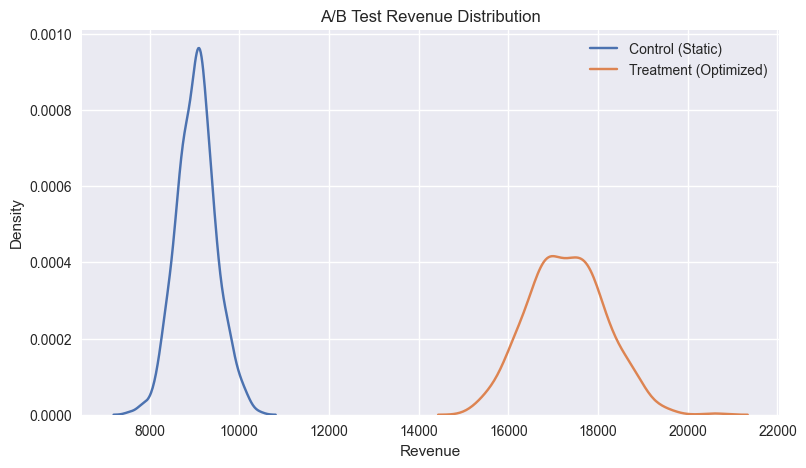

In [18]:
plt.figure(figsize=(9,5))
sns.kdeplot(control_revenues, label="Control (Static)")
sns.kdeplot(treatment_revenues, label="Treatment (Optimized)")

plt.title("A/B Test Revenue Distribution")
plt.xlabel("Revenue")
plt.legend()
plt.show()

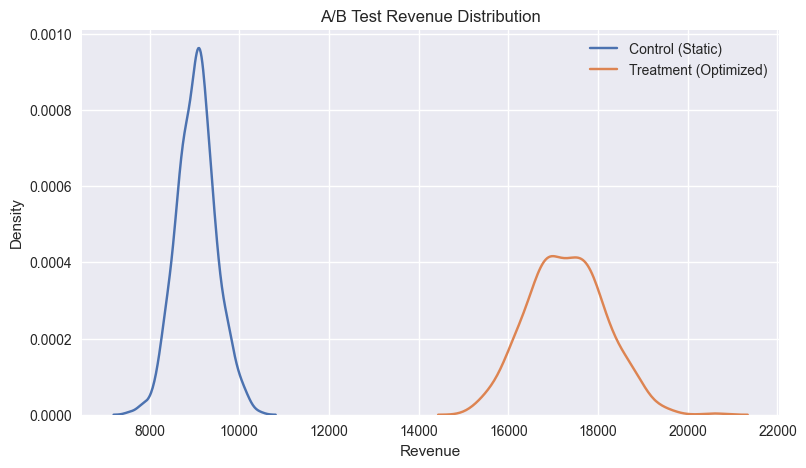

In [12]:
plt.figure(figsize=(9,5))
sns.kdeplot(control_revenues, label="Control (Static)")
sns.kdeplot(treatment_revenues, label="Treatment (Optimized)")

plt.title("A/B Test Revenue Distribution")
plt.xlabel("Revenue")
plt.legend()
plt.show()

**Purpose:**  
Implement multi-period dynamic programming for inventory-aware pricing and simulate A/B pricing experiments.

**Key Components:**
- Formulated Bellman recursion:
  V_t(s) = max [ P × Q(P) + V_{t+1}(s − Q(P)) ]
- Used inventory as state variable.
- Computed optimal price path over time.
- Simulated A/B test:
  - Control: static pricing
  - Treatment: optimized pricing
- Conducted statistical significance testing.
- Compared revenue distributions.

**Why It Matters:**  
Aligns with advanced pricing analytics practices, including dynamic optimization and experimental validation of pricing strategies.
